In [1]:
import numpy as np
from matplotlib import pyplot as plt
import swalkers


NUMBER_OF_SQUARES = 11
NUMBER_OF_GAMES = 10000
START_POS_ALICE = 1
START_POS_BOB = NUMBER_OF_SQUARES - 2

# Set readable font size for plots
plt.rcParams.update({'font.size': 16})


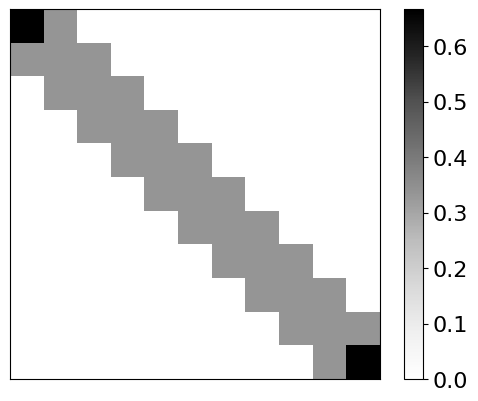

In [2]:
# Build the A matrix for the single walker

A = np.zeros((NUMBER_OF_SQUARES, NUMBER_OF_SQUARES), dtype=float)
for column in range(NUMBER_OF_SQUARES):
    for row in range(NUMBER_OF_SQUARES):
        if column == row:
            A[column, row] = 1/3
        elif column == row - 1 or column == row + 1:
            A[column, row] = 1/3

# Remember to add the boundary conditions
A[0, 0] = 2/3
A[NUMBER_OF_SQUARES - 1, NUMBER_OF_SQUARES - 1] = 2/3


# Print the A matrix with imshow, and mostly white
plt.imshow(A, cmap='Greys', interpolation='nearest')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

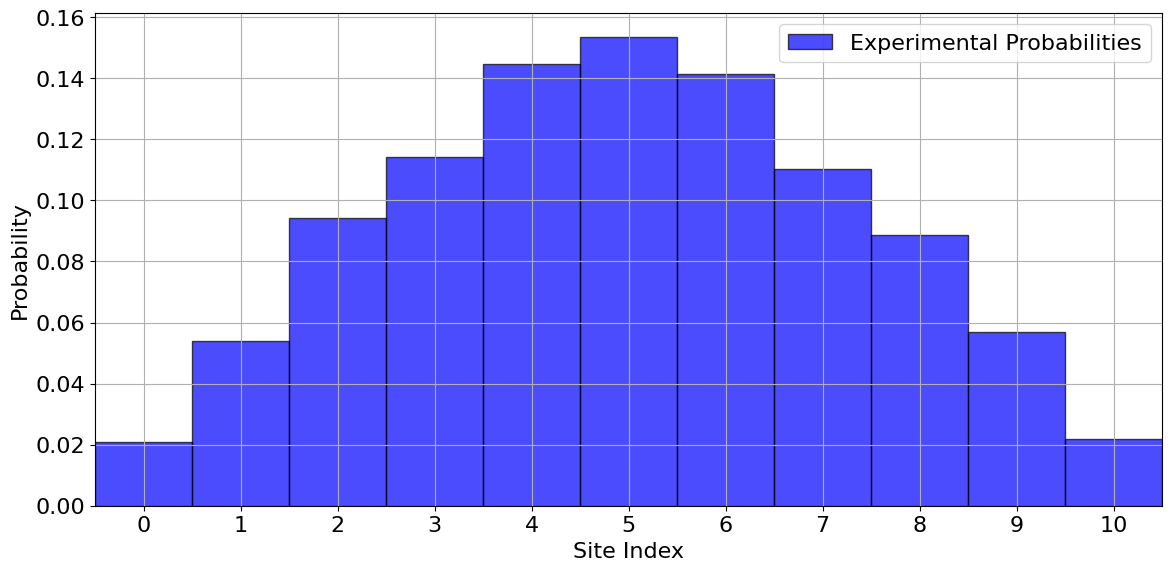

In [3]:
# Get the data for random walkers
random_walker_alice = swalkers.entities.Walker(
    name='Random Alice',
    start_position=START_POS_ALICE,
    world_dimension=NUMBER_OF_SQUARES,
    use_brain=False,
    learn=False
)
random_walker_bob = swalkers.entities.Walker(
    name='Random Bob',
    start_position=START_POS_BOB,
    world_dimension=NUMBER_OF_SQUARES,
    use_brain=False,
    learn=False
)

results = swalkers.simulation.playgames(
    walker_1=random_walker_alice,
    walker_2=random_walker_bob,
    world_dimension=NUMBER_OF_SQUARES,
    reward_function=swalkers.entities.linear_reward,
    number_of_games=NUMBER_OF_GAMES
)

meeting_squares_random = results['meeting_squares']

plt.figure(figsize=(12, 6))
plt.hist(meeting_squares_random, bins=np.arange(-0.5, NUMBER_OF_SQUARES + 0.5, 1), density=True, alpha=0.7, color='blue', edgecolor='black', label='Experimental Probabilities')
plt.xlabel('Site Index')
plt.ylabel('Probability')
plt.xticks(np.arange(0, NUMBER_OF_SQUARES, 1))
plt.xlim(-0.5, NUMBER_OF_SQUARES - 1 + 0.5)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



Eigenvalues: [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  8.82275983e-01
  9.75616867e-01  9.75616867e-01  7.72261452e-01  7.16050311e-01
  6.47245907e-01  6.30252904e-01  9.04388910e-01  9.04388910e-01
  7.91943456e-01  7.91943456e-01  5.84567353e-01  8.82275983e-01
  7.72261452e-01  5.12428773e-01  4.82113292e-01  7.16050311e-01
  4.67538270e-01  6.47245907e-01  4.33614819e-01  6.30252904e-01
  5.84567353e-01  5.12428773e-01  3.80784592e-01 -2.85225662e-01
  4.82113292e-01 -2.85044875e-01  4.67538270e-01 -2.85044875e-01
  4.33614819e-01  2.75409634e-01 -2.85225662e-01  3.80784592e-01
  3.11138179e-01  3.12991049e-01  2.97953538e-01 -2.26027220e-01
 -2.25282261e-01  3.12991049e-01  2.97953538e-01  2.42204772e-01
  3.11138179e-01 -2.26027220e-01 -1.85635681e-01 -1.86053705e-01
  2.75409634e-01 -2.25282261e-01  2.42204772e-01  1.51080038e-01
  2.00667012

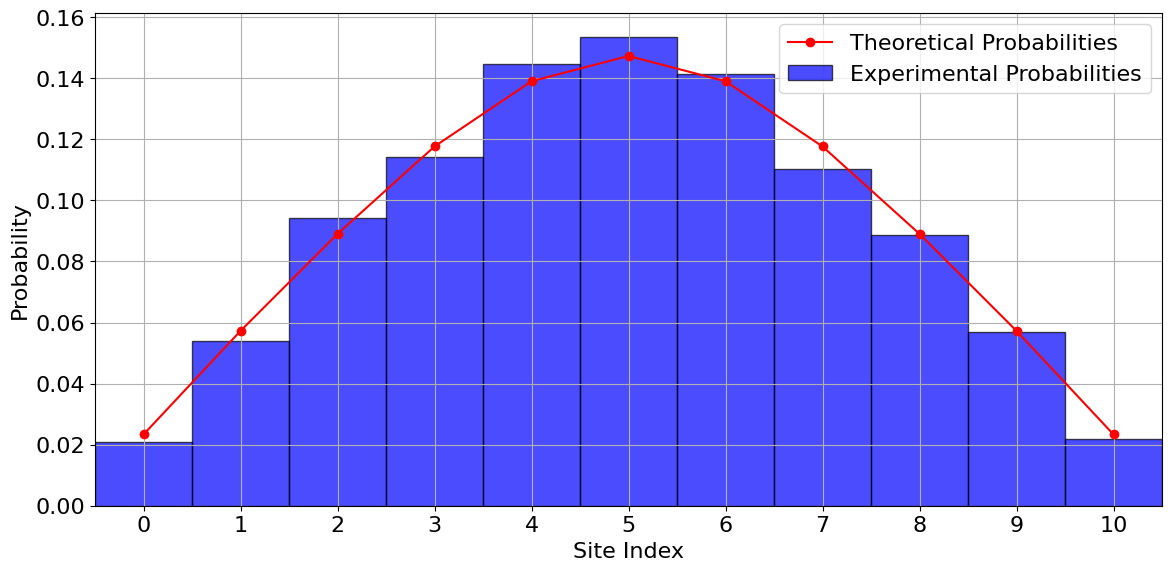

In [4]:
# Get the theoretical cure and confront

alice_policy_tensor = random_walker_alice.get_policy_tensor()
bob_policy_tensor = random_walker_bob.get_policy_tensor()

P0 = swalkers.functions.calculate_starting_distribution_in_tensorspace(
    walker_1_start_pos=START_POS_ALICE,
    walker_2_start_pos=START_POS_BOB,
    world_dimension=NUMBER_OF_SQUARES
)

p = swalkers.functions.calculate_first_encounter_probabilities(
    starting_distribution=P0,
    walker_1_policy_tensor=alice_policy_tensor,
    walker_2_policy_tensor=bob_policy_tensor,
)

# Plot the theoretical cure and confront
plt.figure(figsize=(12, 6))
plt.plot(np.arange(NUMBER_OF_SQUARES), p, marker='o', linestyle='-', color='red', label='Theoretical Probabilities')
plt.hist(meeting_squares_random, bins=np.arange(-0.5, NUMBER_OF_SQUARES + 0.5, 1), density=True, alpha=0.7, color='blue', edgecolor='black', label='Experimental Probabilities')
plt.xlabel('Site Index')
plt.ylabel('Probability')
plt.xticks(np.arange(0, NUMBER_OF_SQUARES, 1))
plt.xlim(-0.5, NUMBER_OF_SQUARES - 1 + 0.5)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

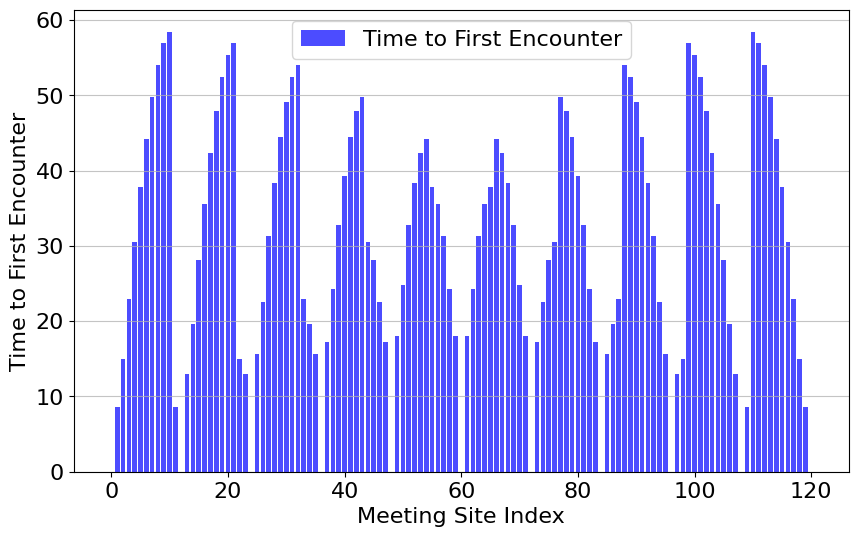

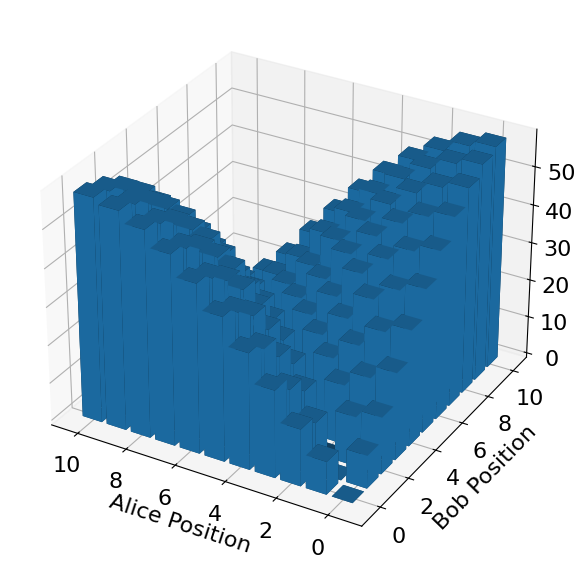

In [ ]:
# Get time vector plot and time matrix plot for the random walkers

policy_tensor_alice = random_walker_alice.get_policy_tensor()
policy_tensor_bob = random_walker_bob.get_policy_tensor()
swalkers.utilities.impose_reflective_boundary_conditions(policy_tensor_alice)
swalkers.utilities.impose_reflective_boundary_conditions(policy_tensor_bob)

A = swalkers.utilities.build_matrix_A(
    policy_tensor_alice,
    policy_tensor_bob
)

A = swalkers.utilities.remove_forbidden_compenetration_processes(A)

time_vector, time_matrix = swalkers.functions.calculate_first_encounter_times(A)

# Plot the time vectors as a bar plot

plt.figure(figsize=(10, 6))
plt.bar(np.arange(NUMBER_OF_SQUARES**2), time_vector, color='blue', alpha=0.7, label='Time to First Encounter')
plt.xlabel('Meeting Site Index')
plt.ylabel('Time to First Encounter')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

time_matrix = np.array(time_matrix)
nrows, ncols = time_matrix.shape

# Create a meshgrid for bar positions
xpos, ypos = np.meshgrid(np.arange(ncols), np.arange(nrows), indexing="xy")
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)  # All bars start at height 0

# Bar dimensions
dx = dy = 0.8  # Width and depth of bars
dz = time_matrix.flatten()  # Heights of the bars

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.bar3d(xpos-0.5, ypos-0.5, zpos, dx, dy, dz, shade=True)

ax.set_xlabel('Alice Position')
ax.set_ylabel('Bob Position')
ax.invert_xaxis()  # Invert x-axis to match the original matrix orientation

plt.tight_layout()
plt.show()

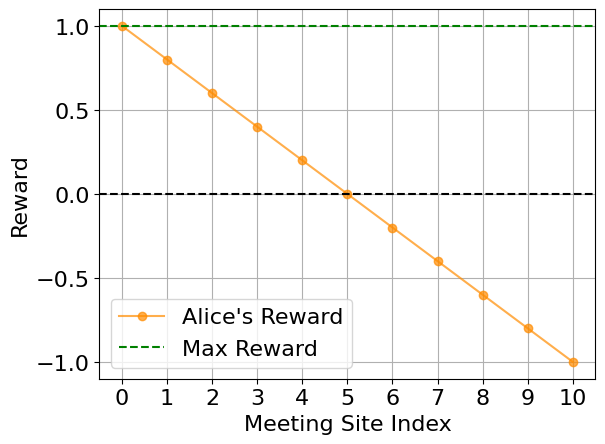

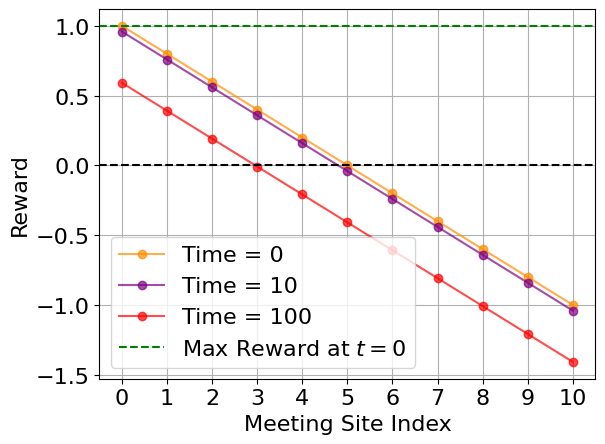

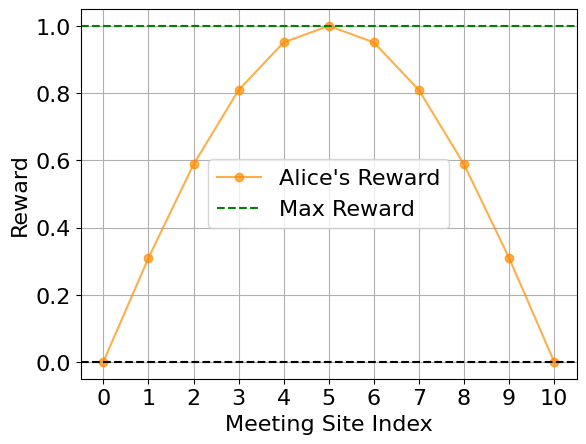

In [6]:
reward_functions = []

reward_functions.append(swalkers.entities.linear_reward)

reward_functions.append(swalkers.entities.time_dependent_linear_reward)

reward_functions.append(swalkers.entities.sinusoidal_reward)

#reward_functions.append(swalkers.entities.high_frequency_sinusoidal_reward)

max_rewards = []

# Plot linear reward function

x = np.arange(NUMBER_OF_SQUARES)
y = [reward_functions[0](i, NUMBER_OF_SQUARES)[0] for i in x]
plt.plot(x, y, color='darkorange', alpha=0.7, label='Alice\'s Reward', marker='o')
plt.xlabel('Meeting Site Index')
plt.ylabel('Reward')
plt.xticks(x)
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='green', linestyle='--', label='Max Reward')
plt.legend()
plt.grid()
plt.show()

# Plot time dependent reward function

x = np.arange(NUMBER_OF_SQUARES)
y_0 = [reward_functions[1](i, NUMBER_OF_SQUARES, time=0)[0] for i in x]
y_10 = [reward_functions[1](i, NUMBER_OF_SQUARES, time=10)[0] for i in x]
y_100 = [reward_functions[1](i, NUMBER_OF_SQUARES, time=100)[0] for i in x]
plt.plot(x, y_0, color='darkorange', alpha=0.7, label='Time = 0', marker='o')
plt.plot(x, y_10, color='purple', alpha=0.7, label='Time = 10', marker='o')
plt.plot(x, y_100, color='red', alpha=0.7, label='Time = 100', marker='o')
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='green', linestyle='--', label='Max Reward at $t=0$')
plt.xlabel('Meeting Site Index')
plt.ylabel('Reward')
plt.xticks(x)
plt.legend()
plt.grid()
plt.show()

# Plot sinusoidal reward function

x = np.arange(NUMBER_OF_SQUARES)
y = [reward_functions[2](i, NUMBER_OF_SQUARES)[0] for i in x]
plt.plot(x, y, color='darkorange', alpha=0.7, label='Alice\'s Reward', marker='o')
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='green', linestyle='--', label='Max Reward')
plt.xlabel('Meeting Site Index')
plt.ylabel('Reward')
plt.xticks(x)
plt.legend()
plt.grid()
plt.show()



In [7]:
# Train the walkers with different reward functions

policy_entropy_results = {}
A_entropy_results = {}
alice_reward_results = {}
trained_walkers = {}

for reward_function in reward_functions:

    # Initialize the walkers
    walker_alice = swalkers.entities.Walker(
        name='Alice',
        start_position=START_POS_ALICE,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=True,
        learn=True
    )
    walker_bob = swalkers.entities.Walker(
        name='Bob',
        start_position=START_POS_BOB,
        world_dimension=NUMBER_OF_SQUARES,
        use_brain=False,
        learn=False,
    )

    results = swalkers.simulation.playgames(
        walker_alice, walker_bob, NUMBER_OF_SQUARES, reward_function, NUMBER_OF_GAMES, annealing=True
        )
    
    policy_entropy_results[reward_function.__name__] = results['policy_entropy_list']
    A_entropy_results[reward_function.__name__] = results['A_entropy_list']
    trained_walkers[reward_function.__name__] = {'walker_alice': walker_alice, 'walker_bob': walker_bob}
    alice_reward_results[reward_function.__name__] = results['walker_1_rewards']
    number_of_comp_prev = results['number_of_compenetrations_prevented']
    percent_affected_by_comp = number_of_comp_prev / NUMBER_OF_GAMES * 100

    print(f'Number of compenetrations prevented: {number_of_comp_prev}')
    print(f'Percentage of games affected by compenetrations: {percent_affected_by_comp:.2f}%')



Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 1506
Percentage of games affected by compenetrations: 15.06%


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 1228
Percentage of games affected by compenetrations: 12.28%


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Number of compenetrations prevented: 2035
Percentage of games affected by compenetrations: 20.35%


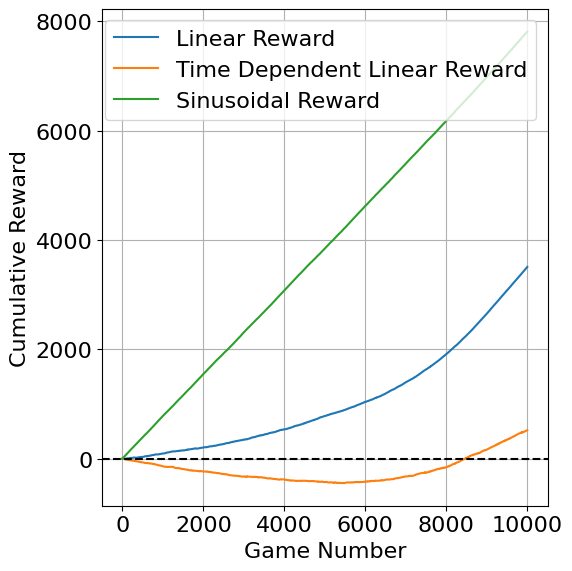

In [8]:
# Make the cumulative reward graphs

plt.figure(figsize=(6, 6))
for key, value in alice_reward_results.items():
    plt.plot(np.cumsum(value), label=key.replace('_', ' ').title())
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Game Number')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

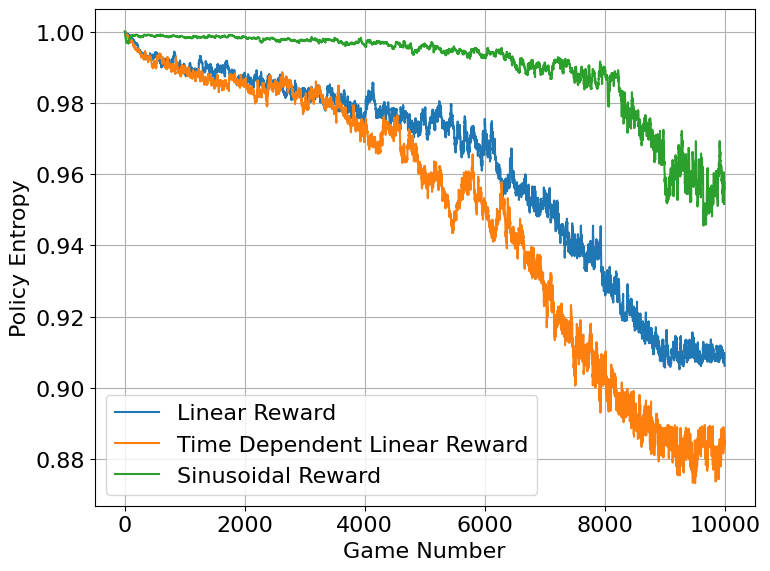

In [9]:
# Make policy entropy graphs

plt.figure(figsize=(8, 6))
for key, value in policy_entropy_results.items():
    plt.plot(value, label=key.replace('_', ' ').title())
plt.xlabel('Game Number')
plt.ylabel('Policy Entropy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

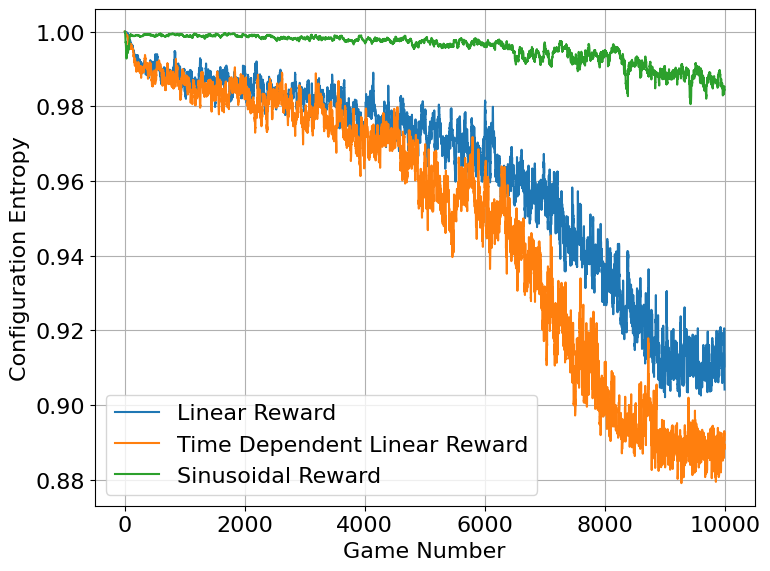

In [27]:
# Make A matrix entropy graphs

plt.figure(figsize=(8, 6))
for key, value in A_entropy_results.items():
    plt.plot(value, label=key.replace('_', ' ').title())
plt.xlabel('Game Number')
plt.ylabel('Configuration Entropy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

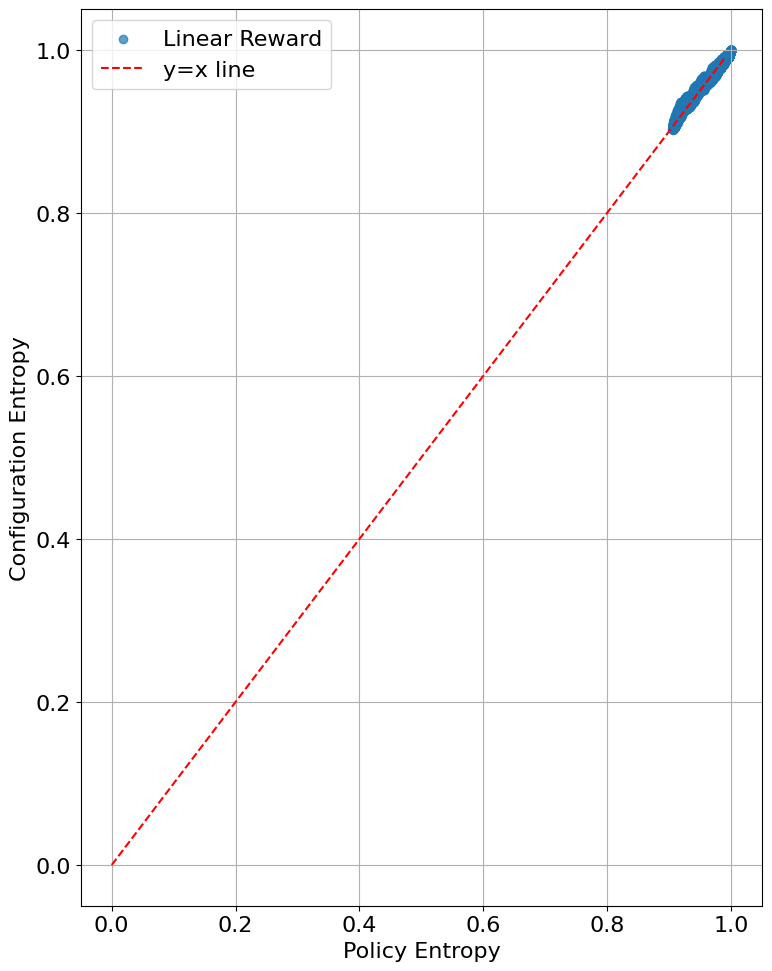

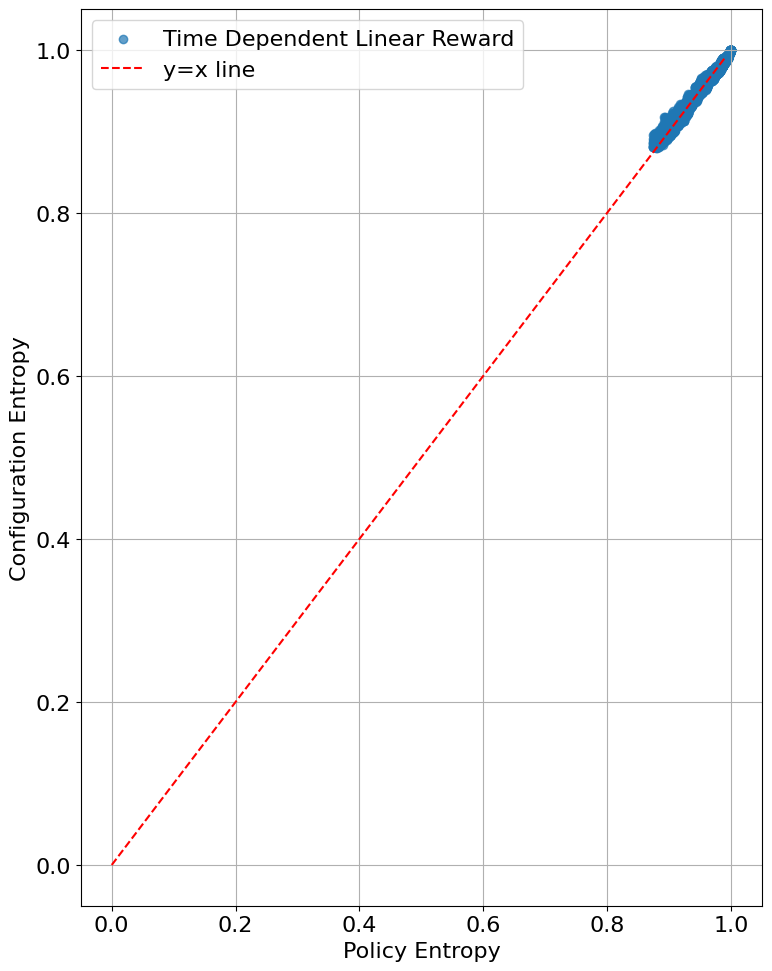

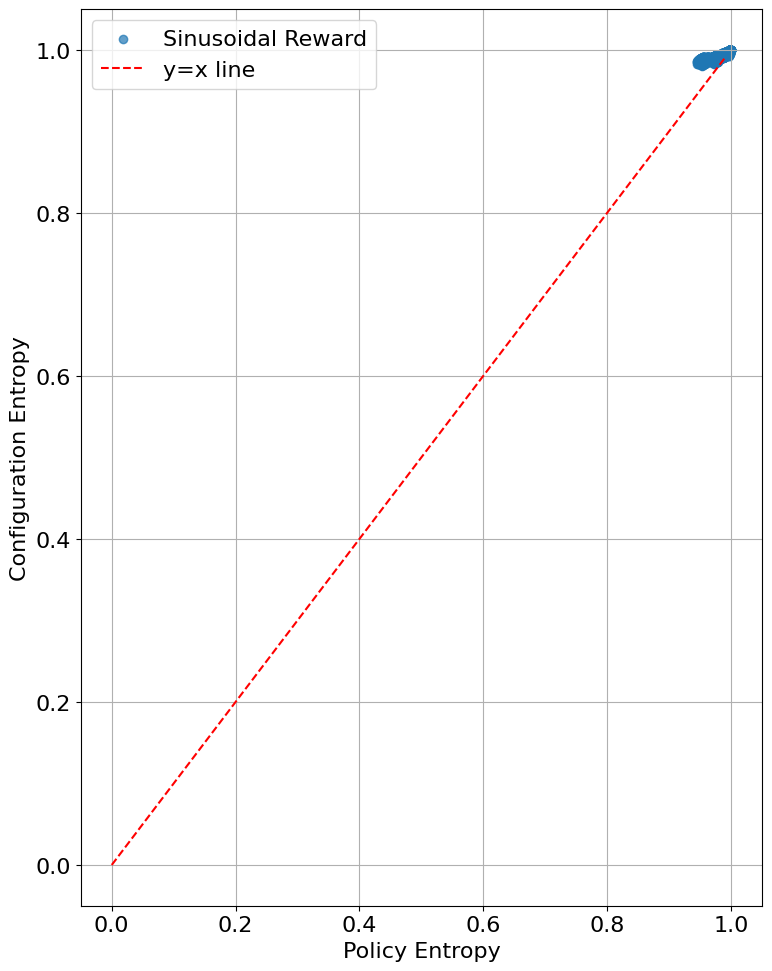

In [11]:
# Plot policy entropy results vs A matrix entropy results
# Policy entropy on the x-axis, A matrix entropy on the y-axis

for key in policy_entropy_results.keys():
    plt.figure(figsize=(8, 10))
    plt.scatter(policy_entropy_results[key], A_entropy_results[key], label=key.replace('_', ' ').title(), alpha=0.7)
    plt.plot(np.arange(0, 1, 0.01), np.arange(0, 1, 0.01), color='red', linestyle='--', label='y=x line')
    plt.xlabel('Policy Entropy')
    plt.ylabel('Configuration Entropy')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

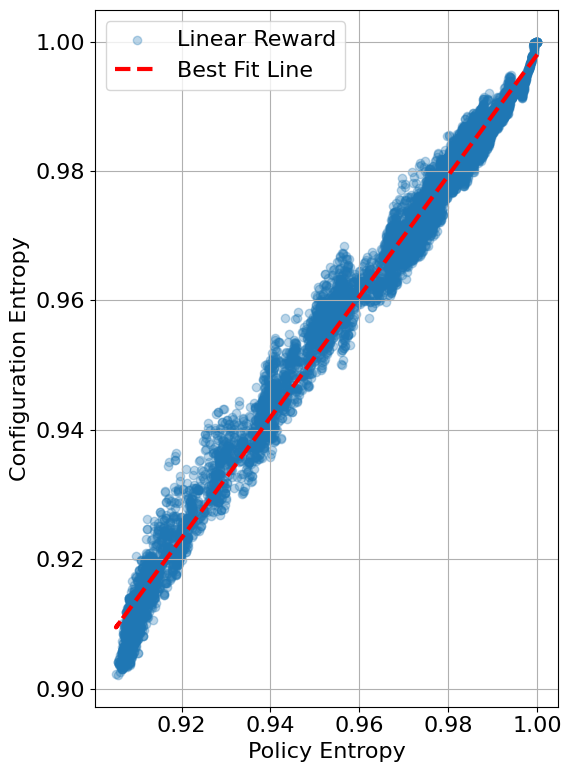

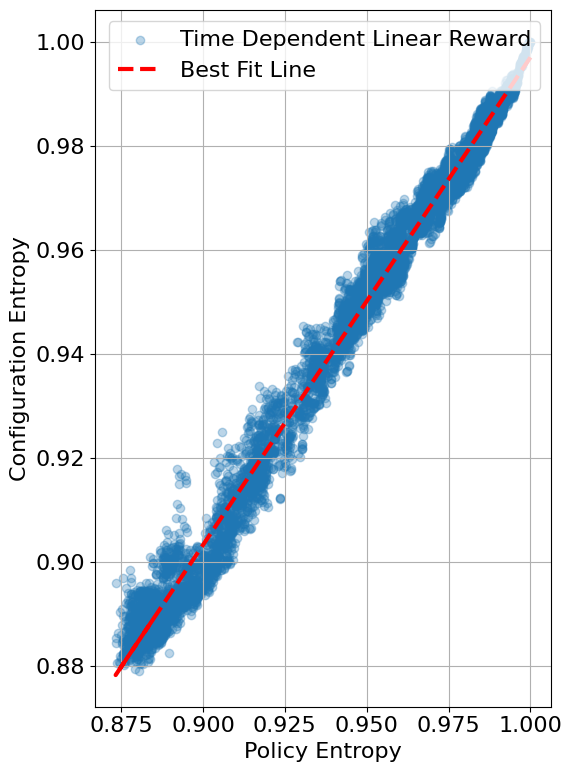

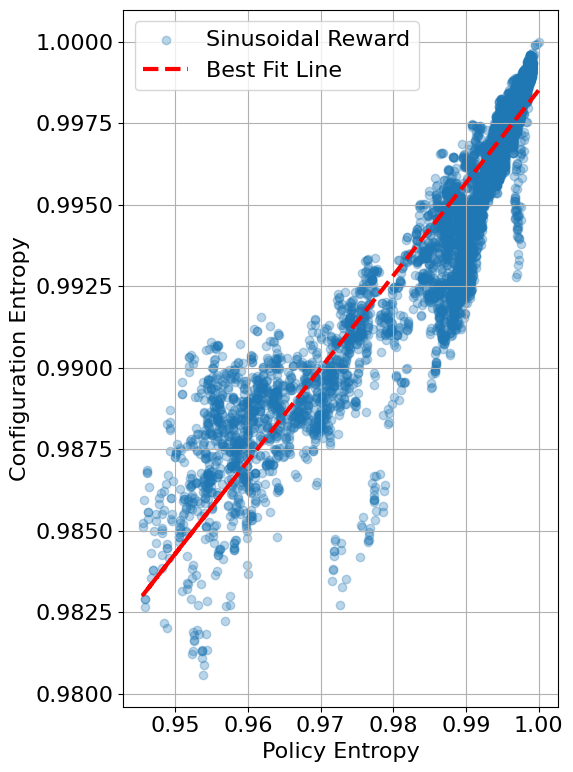

In [34]:
for key in policy_entropy_results.keys():
    x = np.array(policy_entropy_results[key])
    y = np.array(A_entropy_results[key])

    # Fit a line (1st degree polynomial)
    slope, intercept = np.polyfit(x, y, 1)
    best_fit_line = slope * x + intercept

    plt.figure(figsize=(6, 8))
    plt.scatter(x, y, label=key.replace('_', ' ').title(), alpha=0.3)
    plt.plot(x, best_fit_line, color='red', linestyle='--', label='Best Fit Line', linewidth=3)

    plt.xlabel('Policy Entropy')
    plt.ylabel('Configuration Entropy')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

In [12]:
meeting_squares_results_greedy = {}

# Collect meeting squares for each trained walker
for reward_function, walkers in trained_walkers.items():
    walker_alice = walkers['walker_alice']
    walker_bob = walkers['walker_bob']

    walker_alice.learn = False
    walker_alice.greedy = True

    results = swalkers.simulation.playgames(
        walker_1=walker_alice,
        walker_2=walker_bob,
        world_dimension=NUMBER_OF_SQUARES,
        reward_function=swalkers.entities.linear_reward,
        number_of_games=NUMBER_OF_GAMES
    )

    meeting_squares_results_greedy[reward_function] = results['meeting_squares']

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

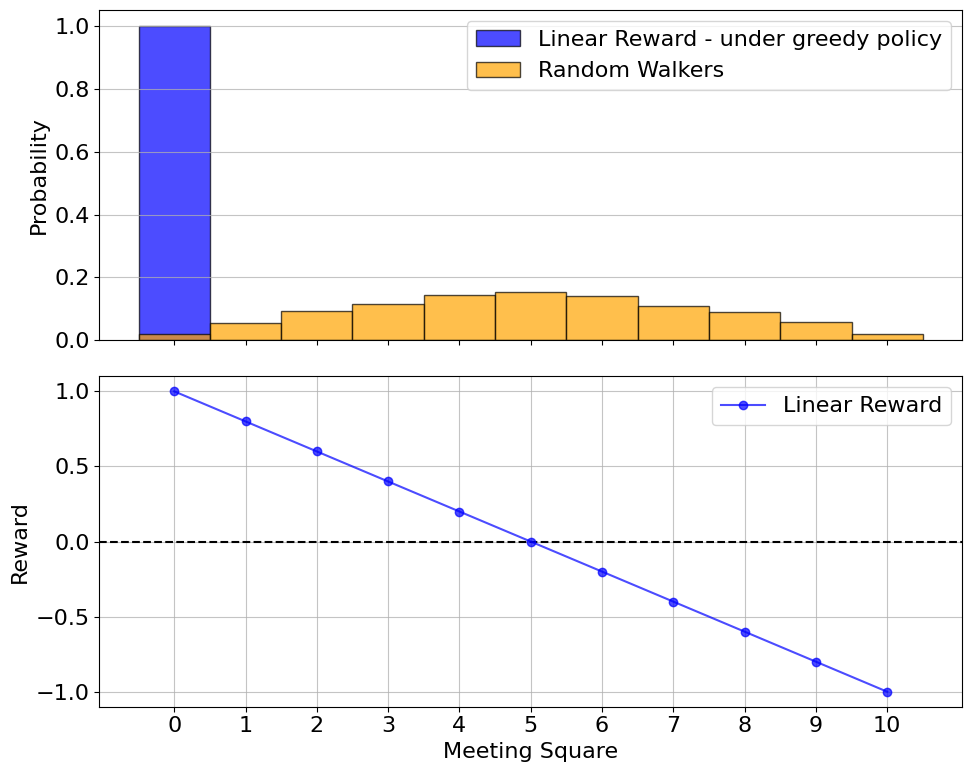

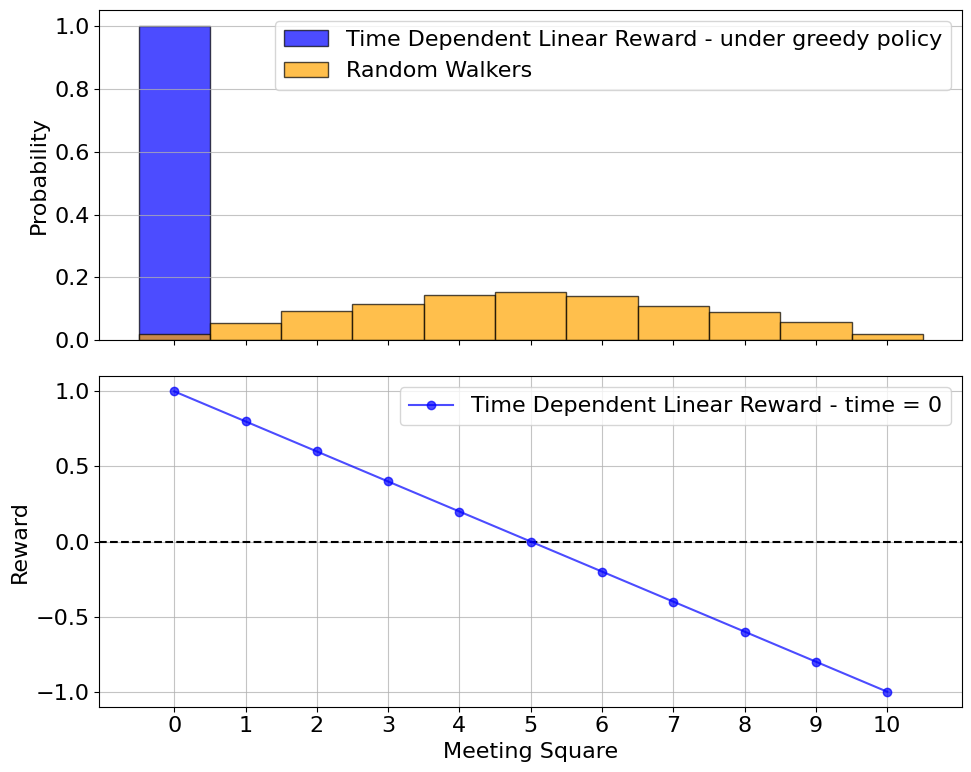

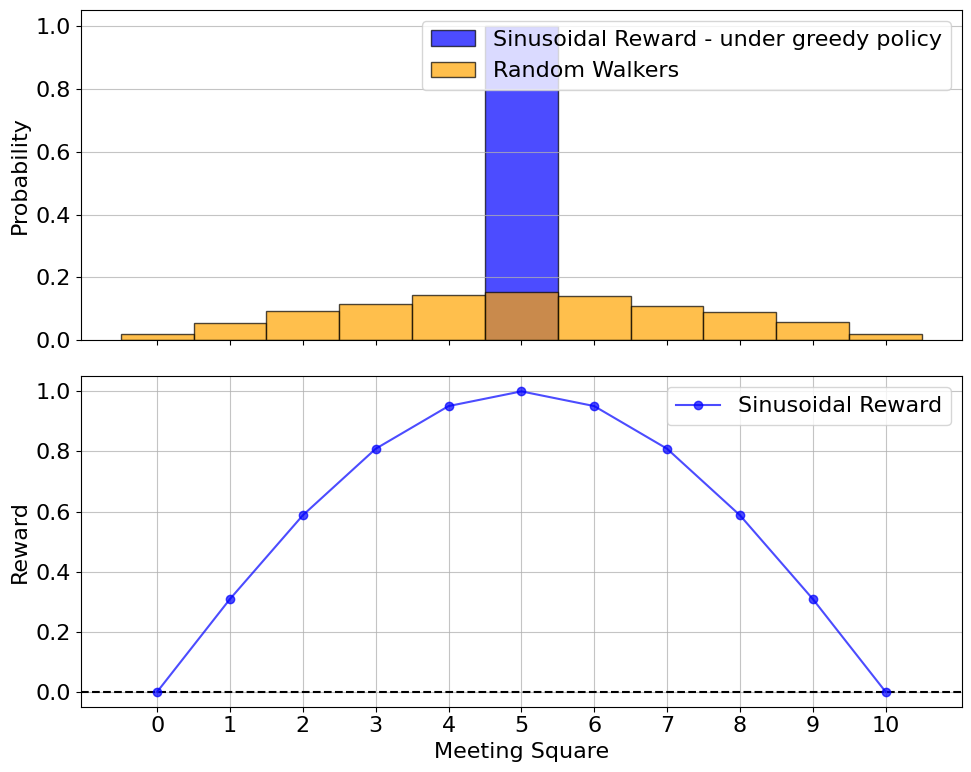

In [13]:
for key, meeting_squares in meeting_squares_results_greedy.items():
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
    
    # Histogram subplot
    ax1.hist(meeting_squares, bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True,
             alpha=0.7, label=f'{key.replace("_", " ").title()} - under greedy policy',
             color='blue', edgecolor='black')
    ax1.hist(meeting_squares_random, bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True,
             alpha=0.7, label='Random Walkers',
             color='orange', edgecolor='black')
    ax1.set_ylabel('Probability')
    ax1.grid(axis='y', alpha=0.75)
    ax1.legend()

    # Reward subplot
    x = np.arange(NUMBER_OF_SQUARES)
    ax2.axhline(0, color='black', linestyle='--')
    if key == 'linear_reward':
        y = [reward_functions[0](i, NUMBER_OF_SQUARES)[0] for i in x]
        ax2.plot(x, y, color='blue', alpha=0.7, label='Linear Reward', marker='o')
    elif key == 'time_dependent_linear_reward':
        y = [reward_functions[1](i, NUMBER_OF_SQUARES, time=0)[0] for i in x]
        ax2.plot(x, y, color='blue', alpha=0.7, label='Time Dependent Linear Reward - time = 0', marker='o')
    elif key == 'sinusoidal_reward':
        y = [reward_functions[2](i, NUMBER_OF_SQUARES)[0] for i in x]
        ax2.plot(x, y, color='blue', alpha=0.7, label='Sinusoidal Reward', marker='o')
    elif key == 'high_frequency_sinusoidal_reward':
        y = [reward_functions[3](i, NUMBER_OF_SQUARES)[0] for i in x]
        ax2.plot(x, y, color='blue', alpha=0.7, label='High Frequency Sinusoidal Reward', marker='o')
    else:
        print(f'Unknown reward function: {key}')
        continue

    ax2.set_xlabel('Meeting Square')
    ax2.set_ylabel('Reward')
    ax2.grid(alpha=0.75)
    ax2.legend()
    ax2.set_xticks(np.arange(NUMBER_OF_SQUARES))

    plt.tight_layout()
    plt.show()


In [20]:
# Plot the first encounter probabilities

meeting_squares_results = {}

# Collect meeting squares for each trained walker
for reward_function, walkers in trained_walkers.items():
    walker_alice = walkers['walker_alice']
    walker_bob = walkers['walker_bob']

    walker_alice.learn = False
    walker_alice.greedy = False
    print(f'Alice\'s policy temperature: {walker_alice.softmax_temperature}')

    results = swalkers.simulation.playgames(
        walker_1=walker_alice,
        walker_2=walker_bob,
        world_dimension=NUMBER_OF_SQUARES,
        reward_function=swalkers.entities.linear_reward,
        number_of_games=NUMBER_OF_GAMES
    )

    meeting_squares_results[reward_function] = results['meeting_squares']

Alice's policy temperature: 0.1


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Alice's policy temperature: 0.1


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Alice's policy temperature: 0.1


Playing:   0%|          | 0/10000 [00:00<?, ?it/s]

Eigenvalues: [ 1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          9.75616867e-01+0.j
  8.82275983e-01+0.j          9.04388910e-01+0.j
  7.91943456e-01+0.j          7.72261452e-01+0.j
  7.16050311e-01+0.j          9.92047046e-01+0.j
  6.47245907e-01+0.j          9.30644512e-01+0.j
  9.11294248e-01+0.j          6.30252904e-01+0.j
  5.84567353e-01+0.j          8.17173550e-01+0.j
  7.77660812e-01+0.j          5.12428773e-01+0.j
  4.82113292e-01+0.j          7.23467778e-01+0.j
  6.64098735e-01+0.j          4.67538270e-01+0.j
  4.33614819e-01+0.j          5.95437837e-01+0.j
  5.55730033e-01+0.j          3.80784592e-01+0.j
 -2.85225662e-01+0.j         -2.85044875e-01+0.j
  4.82326642e-01+0.00459652j  4.82326642e-01-0.00459652j
  3.11138179e-01+0.j          2.97953538e-01+0.j

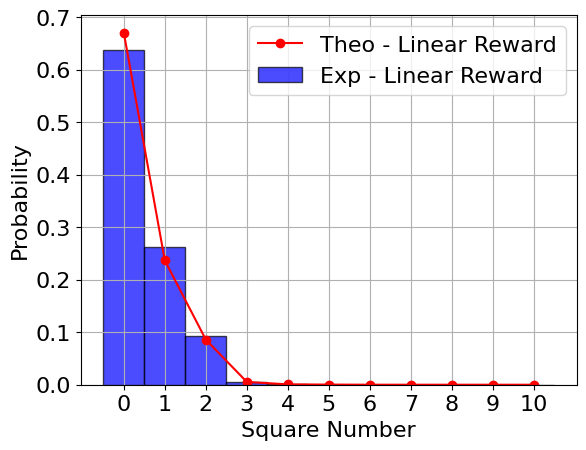

Eigenvalues: [ 1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          9.75616867e-01+0.j
  8.82275983e-01+0.j          9.04388910e-01+0.j
  7.91943456e-01+0.j          7.72261452e-01+0.j
  7.16050311e-01+0.j          9.92551942e-01+0.j
  6.47245907e-01+0.j          9.33976381e-01+0.j
  9.10983983e-01+0.j          6.30252904e-01+0.j
  5.84567353e-01+0.j          8.22038920e-01+0.j
  7.76157701e-01+0.j          5.12428773e-01+0.j
  7.20327580e-01+0.j          6.66666963e-01+0.j
  4.33614819e-01+0.j          4.67538270e-01+0.j
  4.82113292e-01+0.j          5.93862293e-01+0.j
  5.50962085e-01+0.j         -2.85044875e-01+0.j
 -2.85225662e-01+0.j          3.80784592e-01+0.j
  4.81756141e-01+0.j          4.79189561e-01+0.j
 -3.03705958e-01+0.j         -3.00289048e-01+0.j
  2.979

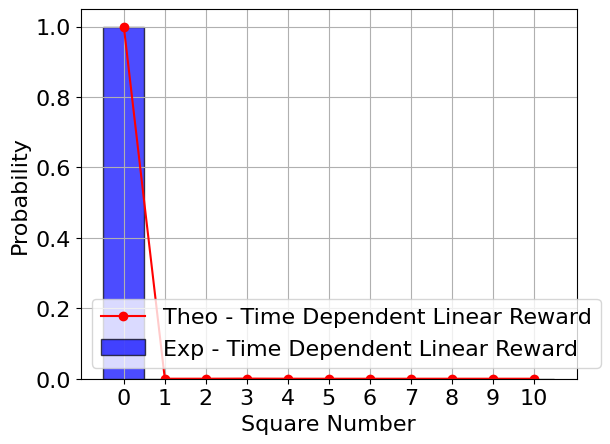

Eigenvalues: [ 1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          1.00000000e+00+0.j
  1.00000000e+00+0.j          9.75616867e-01+0.j
  9.04388910e-01+0.j          8.82275983e-01+0.j
  7.91943456e-01+0.j          7.72261452e-01+0.j
  9.79185301e-01+0.j          7.16050311e-01+0.j
  9.17161654e-01+0.j          8.75988615e-01+0.j
  6.47245907e-01+0.j          6.30252904e-01+0.j
  5.84567353e-01+0.j          7.92322691e-01+0.j
  5.12428773e-01+0.j          7.21639170e-01+0.01043824j
  7.21639170e-01-0.01043824j  6.29387097e-01+0.j
  4.82113292e-01+0.j          4.67538270e-01+0.j
  4.33614819e-01+0.j          5.57366220e-01+0.02894433j
  5.57366220e-01-0.02894433j  5.27241770e-01+0.j
  3.80784592e-01+0.j         -2.85225662e-01+0.j
 -2.85044875e-01+0.j          4.84240342e-01+0.j
  4.42155074e-01+0.j          2.97953538

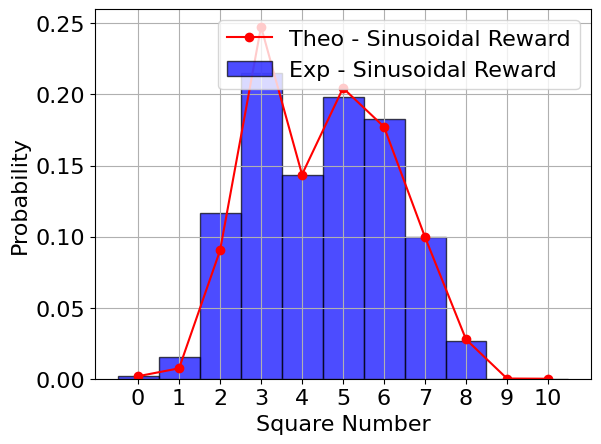

In [26]:
for key, walker_pair in trained_walkers.items():
    alice_policy_tensor = walker_pair['walker_alice'].get_policy_tensor()
    bob_policy_tensor = walker_pair['walker_bob'].get_policy_tensor()

    p = swalkers.functions.calculate_first_encounter_probabilities(
        starting_distribution=P0,
        walker_1_policy_tensor=alice_policy_tensor,
        walker_2_policy_tensor=bob_policy_tensor,
    )

    
    plt.plot(np.arange(NUMBER_OF_SQUARES), p, marker='o', linestyle='-', label=f'Theo - {key.replace("_", " ").title()}', color='red')
    plt.hist(meeting_squares_results[key], bins=np.arange(NUMBER_OF_SQUARES + 1) - 0.5, density=True, alpha=0.7, label=f'Exp - {key.replace("_", " ").title()}', color='blue', edgecolor='black')
    plt.xlabel('Square Number')
    plt.ylabel('Probability')
    plt.xticks(np.arange(NUMBER_OF_SQUARES))
    plt.legend()
    plt.grid()
    plt.show()

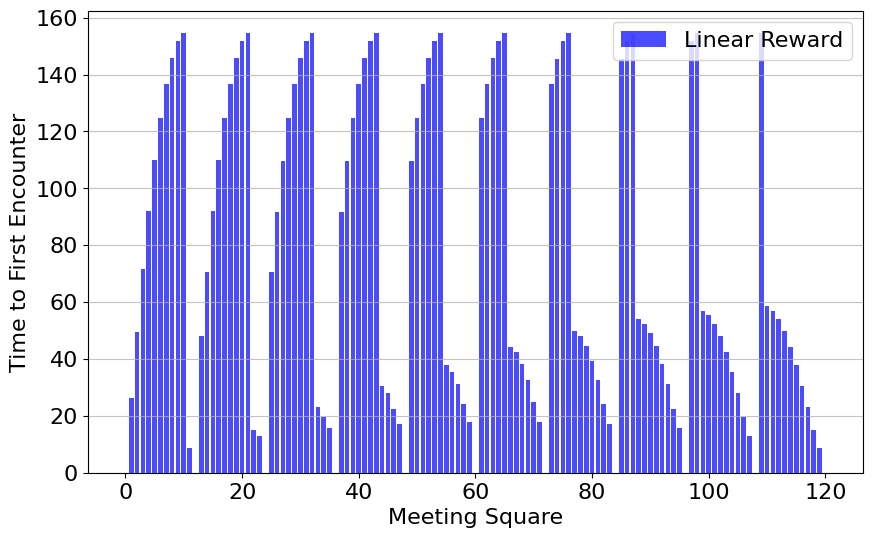

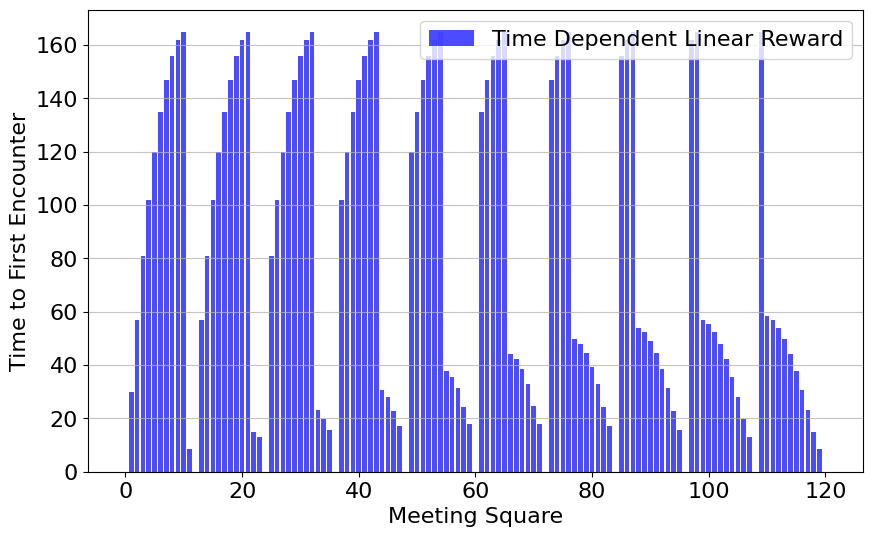

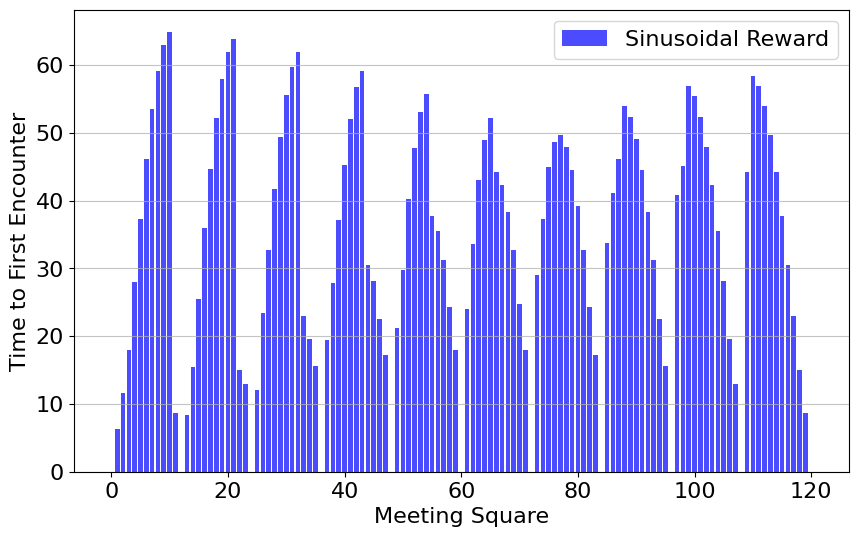

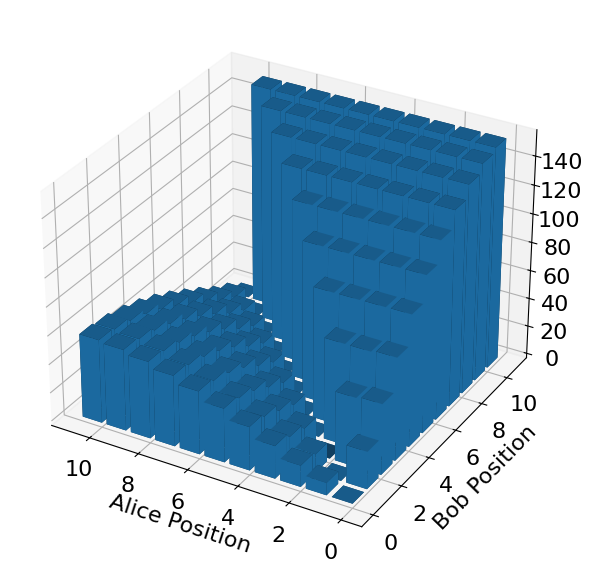

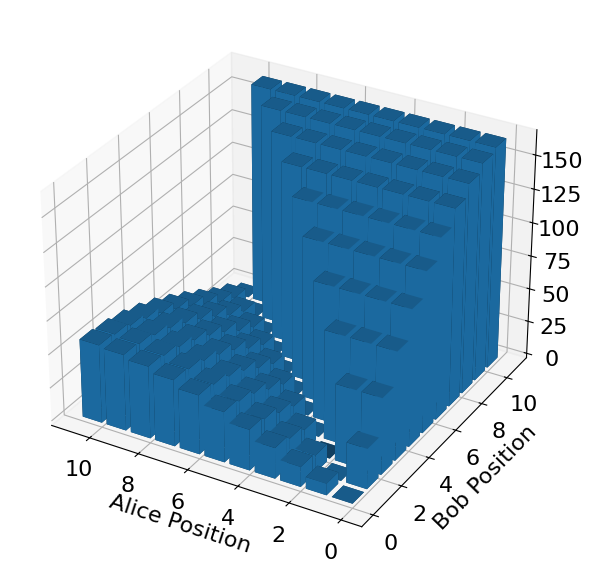

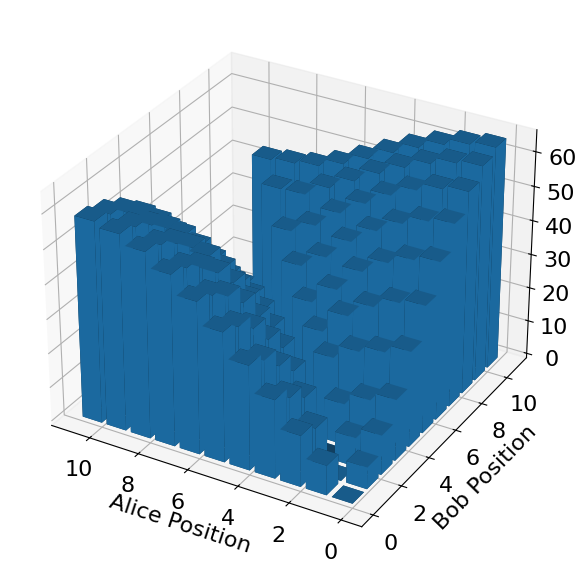

In [ ]:

time_vectors = {}
time_matrices = {}

for key, couple in trained_walkers.items():
    walker_alice = couple['walker_alice']
    walker_bob = couple['walker_bob']
    
    alice_prob_tensor = walker_alice.get_policy_tensor()
    bob_prob_tensor = walker_bob.get_policy_tensor()

    swalkers.utilities.impose_reflective_boundary_conditions(alice_prob_tensor)
    swalkers.utilities.impose_reflective_boundary_conditions(bob_prob_tensor)

    A = swalkers.utilities.build_matrix_A(alice_prob_tensor, bob_prob_tensor)
    A = swalkers.utilities.remove_forbidden_compenetration_processes(A)
    time_vector, time_matrix = swalkers.functions.calculate_first_encounter_times(A)

    time_vectors[key] = time_vector
    time_matrices[key] = time_matrix

# Plot the time vectors as a bar plot
for key, time_vector in time_vectors.items():
    plt.figure(figsize=(10, 6))
    plt.bar(np.arange(NUMBER_OF_SQUARES**2), time_vector, color='blue', alpha=0.7, label=key.replace('_', ' ').title())
    plt.xlabel('Meeting Square')
    plt.ylabel('Time to First Encounter')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

for key, matrix in time_matrices.items():
    matrix = np.array(matrix)
    nrows, ncols = matrix.shape

    # Create a meshgrid for bar positions
    xpos, ypos = np.meshgrid(np.arange(ncols), np.arange(nrows), indexing="xy")
    xpos = xpos.flatten()
    ypos = ypos.flatten()
    zpos = np.zeros_like(xpos)  # All bars start at height 0

    # Bar dimensions
    dx = dy = 0.8  # Width and depth of bars
    dz = matrix.flatten()  # Heights of the bars

    # Plotting
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

    ax.set_xlabel('Alice Position')
    ax.set_ylabel('Bob Position')
    ax.invert_xaxis()  # Invert x-axis to match the original matrix orientation

    plt.tight_layout()
    plt.show()